# Stage 08: the learned ranking weights

**The score function's weights, learned from the corpus by pairwise
ranking — and the retirement of the grid ranker that used to live here.**

## What happened to the old stage 08

This folder held a gradient-boosted grid ranker (real grids against
resampled and jittered line sets) that cut the shortlist from 15 to 5.
Under the four-variant design it is retired: its job — a second learned
opinion about the same geometry — is exactly what the V1/V2/V4 judges do,
and keeping both would double-count one signal (loophole L7). Its
successor keeps the stage's real purpose, *the learned component of the
ranking*, in a form whose output is five readable numbers instead of an
opaque model.

## The only non-circular formulation

Two formulations were rejected before this one:

* regressing a model onto the algorithmic score's output — a tautology; the
  student would have trained a copy of the thing being compared against
  (loophole L6);
* training on the judges' real-versus-corrupted signal — then the "learned
  score" and the judge are the same model applied twice, and V1 collapses
  into V3 with extra steps.

What remains is **learning to rank**: for each of 11,098 corpus plans, the
derived ground-truth arrangement is the positive, and up to five
alternatives *enumerated over that same plan's grid* (the full lattice,
line subsets under both placement policies) are the negatives. A logistic
model without intercept is fitted on the **differences of the robustly
normalised score terms**, so that penalty(ground truth) < penalty(alt) as
often as the data allows. Linear on term differences means the coefficients
*are* the weights, directly comparable to the algorithmic vector of ones.

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "09_full_pipeline"))
import pipeline as P

learned = json.loads((Path("..") / "data" / "learned_weights.json").read_text())
summary = pd.read_csv(Path("..") / "data" / "rank_pairs_summary.csv")

print(f"{learned['n_pairs']:,} ranking pairs from {learned['n_plans']:,} plans")
print(f"pairwise accuracy, held-out plans over 5 grouped splits:")
print(f"  learned weights      {learned['pairwise_accuracy_test_mean']:.3f} "
      f"± {learned['pairwise_accuracy_test_std']:.3f}")
print(f"  algorithmic (ones)   {learned['algorithmic_vector_accuracy_same_fold']:.3f}")
pd.DataFrame({
    "weight (normalised)": learned["weights"],
    "std over splits": learned["coefficient_std_over_splits"]}).round(3)

52,724 ranking pairs from 11,098 plans
pairwise accuracy, held-out plans over 5 grouped splits:
  learned weights      0.894 ± 0.006
  algorithmic (ones)   0.747


,weight (normalised),std over splits
t_density,-0.424,0.033
t_span_demand,0.380,0.166
t_irregularity,-0.456,0.062
t_off_wall,2.771,0.089
t_repetition,0.969,0.013


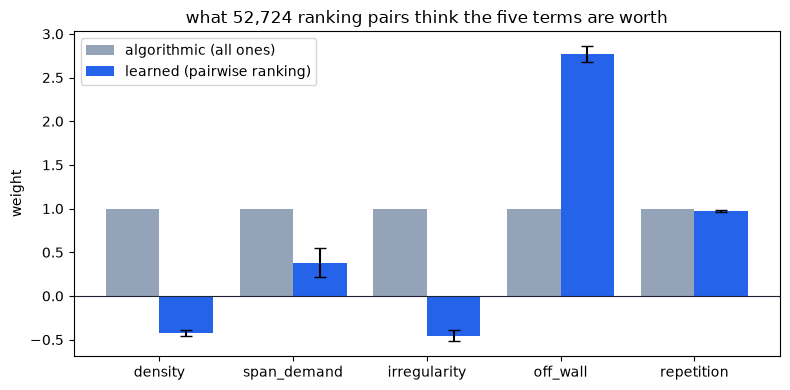

In [2]:
w = learned["weights"]
sd = learned["coefficient_std_over_splits"]
terms = P.SCORE_TERMS
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(terms))
ax.bar(x - 0.2, [1.0] * len(terms), 0.4, color="#94a3b8",
       label="algorithmic (all ones)")
ax.bar(x + 0.2, [w[t] for t in terms], 0.4, color="#2563eb",
       yerr=[sd[t] for t in terms], capsize=4,
       label="learned (pairwise ranking)")
ax.axhline(0, color="#1c2430", lw=0.8)
ax.set_xticks(x, [t.replace("t_", "") for t in terms])
ax.set_ylabel("weight"); ax.legend()
ax.set_title("what 52,724 ranking pairs think the five terms are worth")
fig.tight_layout()
fig.savefig(Path("..") / "figures" / "08_learned_weights.png", dpi=150,
            bbox_inches="tight")
plt.show()

In [3]:
test = summary[(summary.scope == "test")]
print("pairwise accuracy on held-out plans, by slice (mean over splits):")
print(test.groupby("kind").gt_ranked_better.mean().round(3).to_string())

pairwise accuracy on held-out plans, by slice (mean over splits):
kind
CubiCasa          0.820
Swiss             0.924
all               0.894
lattice-full      0.958
lattice-subset    0.984
walls-subset      0.773


## Reading the learned vector

* **`t_off_wall` dominates (≈ +2.7)** — with a stated caveat: the ground
  truth's off-wall fraction is zero *by construction* (derived columns sit
  inside walls by definition), so part of this weight restates the
  derivation rather than discovering practice. It is still the honest
  signal at inference, where candidates genuinely differ on it.
* **`t_span_demand` (≈ +0.4) and `t_repetition` (≈ +0.9)** agree with the
  design intuition: real arrangements have shorter loaded spans and more
  repeated bays than alternatives over the same grid.
* **`t_density` (≈ −0.4) and `t_irregularity` (≈ −0.46) come out
  negative.** The data disagrees with the designerly prior: the derived
  ground truth is *denser* and *less regular* than the enumerated
  alternatives, because it is an equivalent-frame reading of a wall-bearing
  building — columns stand where party walls stand, and party walls follow
  rooms, not modules. This single result predicts the central pattern of
  the stage 12 tables: the equal-weight score ranks the ground truth
  poorly, and the learned weights close most of that gap.

Both vectors go forward to stage 12 and every variant is evaluated under
both (`--score algo|learned`); a legitimate outcome would have been the
algorithmic vector matching the learned one, and the comparison is run
rather than assumed.